# Spaceship Titanic — a guided EDA

**EDA** stands for *exploratory data analysis*: the part of a data project where you look at the
data and try to understand it, before you build anything that makes predictions.

This notebook is written for someone new to data. Every section says **why** we are running a
piece of code, not just what it does. Jargon is defined the first time it appears, and there is
a glossary at the bottom.

---

## The problem

The Spaceship Titanic hit a spacetime anomaly. Some passengers were **transported** to another
dimension; others were not. We have records for 8,693 passengers where we know what happened,
and 4,277 where we do not.

Our job: work out *what kind of passenger got transported*.

That is a **binary classification** problem — for each passenger the answer is one of two
things, `True` or `False`.

## How to use this notebook

- Run cells top to bottom with `Shift + Enter`.
- Every number here has been checked against the analysis scripts in `src/`. If you change a
  cell and a number moves, that is you learning something, not a bug.
- The three sections marked **★ HIGHLIGHT** are the ones worth slowing down on. They are where
  the dataset stops being a spreadsheet and starts being interesting.

## What you will learn

| Section | Idea |
|---|---|
| 1 | Why you always establish a **baseline** before believing any result |
| 3 | Why "2% missing" can quietly cost you a quarter of your data |
| 4 | How to find features **hidden inside text columns** |
| 5 ★ | Spotting a **deterministic rule**, and why "missing" is not always "unknown" |
| 6 ★ | **Confounding** — the reason a naive comparison can point the wrong way |
| 7 ★ | How an **ID column** can turn out to be the strongest predictor in the file |
| 9 | **Uncertainty** — when a difference is real and when it is noise |

## 0. Setup

We import the project's own helper modules rather than writing everything from scratch.

- `src/load.py` reads the CSV files and does the parsing work. It is the **single source of
  truth** — if we each wrote our own version of the parsing, our numbers would drift apart.
- `src/viz.py` holds the chart styling, the colour palette, and two statistics helpers we will
  meet later.

`load()` gives back three tables:

| name | what it is |
|---|---|
| `train` | 8,693 passengers **with** the answer (`Transported`) |
| `test` | 4,277 passengers **without** it — this is what Kaggle scores you on |
| `combined` | both stacked together, 12,970 rows |

**The rule to remember:** anything that involves the answer must use `train` only, because
`test` has no answer column. Facts about *structure* — how many values are missing, how cabins
are numbered — can use `combined`, which gives us more rows to look at. We will say which one
we are using every time.

In [1]:
import sys
from pathlib import Path

# Make the project's src/ importable from inside notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import load as L
import viz

# viz.py sets the "Agg" backend (for scripts that only write files).
# In a notebook we want charts to appear inline as well, so we save AND display.
from IPython.display import Image, display

(ROOT / "figures" / "nb").mkdir(parents=True, exist_ok=True)

def show(fig, name, title=None, subtitle=None):
    """Save a figure to figures/nb/ and display it inline."""
    path = viz.save(fig, f"nb/{name}", title, subtitle)
    display(Image(str(path)))

print("python     :", sys.version.split()[0])
print("pandas     :", pd.__version__)
print("project    :", ROOT)

python     : 3.12.14
pandas     : 3.0.5
project    : /home/user/spaceship-titanic


In [2]:
train, test, combined = L.load()

print(f"train    : {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"test     : {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"combined : {combined.shape[0]:,} rows")
print()
print("test has no answer column:", L.TARGET not in test.columns)

train    : 8,693 rows x 27 columns
test     : 4,277 rows x 26 columns
combined : 12,970 rows

test has no answer column: True


## 1. The baseline — the number every other number is judged against

Before looking at a single feature, ask: **how often does the thing we are predicting happen at
all?**

This is the **baseline** (also called the *marginal rate*). It matters because it is the score
you would get by not thinking at all — just guessing the more common answer every time. Any
feature we find has to beat it, or it is worthless.

In [3]:
rate = train[L.TARGET].mean()
print(f"Transported = True : {train[L.TARGET].sum():,} of {len(train):,}")
print(f"baseline rate      : {rate:.1%}")
print()
print("So a model that guesses 'True' for everyone scores about 50.4%.")
print("Remember this number. Every rate below is read against it.")

Transported = True : 4,378 of 8,693
baseline rate      : 50.4%

So a model that guesses 'True' for everyone scores about 50.4%.
Remember this number. Every rate below is read against it.


**50.4%.** That is an unusually balanced dataset — real-world problems are often 95%/5%, which
brings its own headaches. Here we are spared that, which is one reason this competition is a
good first one.

From now on, when you see a rate like "65%", the interesting part is not the 65 — it is the
**+15 points above 50.4%**.

> **Reading tip: "pp" means percentage points.** Going from 50% to 65% is a rise of 15
> *percentage points*, not 15 percent. Keeping these separate saves a lot of confusion later.

## 2. First look at the raw table

Three commands you will use on literally every dataset you ever open:

- `.head()` — show the first few rows, so you can see what a record actually looks like
- `.info()` — column names, data types, and how many values are present
- `.describe()` — min / max / mean / quartiles for the numeric columns

Look at these before forming any opinion.

In [4]:
train.head(5)[["PassengerId", "HomePlanet", "CryoSleep", "Cabin", "Destination",
               "Age", "VIP", "RoomService", "FoodCourt", "Name", "Transported"]]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,Willy Santantines,True


In [5]:
# Only the original columns — load.py adds some of its own, which we meet in section 4.
original = ["PassengerId", "HomePlanet", "CryoSleep", "Cabin", "Destination", "Age", "VIP",
            "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "Name", "Transported"]
train[original].info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [6]:
train[["Age"] + L.SPEND_COLS].describe().round(1)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.0,8512.0,8510.0,8485.0,8510.0,8505.0
mean,28.8,224.7,458.1,173.7,311.1,304.9
std,14.5,666.7,1611.5,604.7,1136.7,1145.7
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,19.0,0.0,0.0,0.0,0.0,0.0
50%,27.0,0.0,0.0,0.0,0.0,0.0
75%,38.0,47.0,76.0,27.0,59.0,46.0
max,79.0,14327.0,29813.0,23492.0,22408.0,24133.0


Two things are already visible in `.describe()`:

1. **The spending columns are wildly skewed.** Look at `RoomService`: the median (the `50%` row)
   is 0, but the maximum is over 14,000. Most people spend nothing; a few spend enormous amounts.
   An average is a poor summary of a column that looks like this.
2. **`Age` has a minimum of 0.** Is that a real newborn, or is 0 being used as a code for
   "unknown"? This is a genuinely important question and it has a real answer — we check it in
   section 8.

## 3. Missing data — the trap that eats a quarter of your rows

Real datasets have gaps. The beginner's instinct is to check "what percentage of this column is
missing?", see a small number, and move on. Let us do that first, then see why it misleads.

In [7]:
miss = pd.DataFrame({
    "missing": combined[original[:-1]].isna().sum(),
    "pct": combined[original[:-1]].isna().mean() * 100,
}).sort_values("pct", ascending=False).round(2)
miss

,missing,pct
CryoSleep,310,2.39
ShoppingMall,306,2.36
Cabin,299,2.31
VIP,296,2.28
Name,294,2.27
FoodCourt,289,2.23
HomePlanet,288,2.22
Spa,284,2.19
Destination,274,2.11
Age,270,2.08


Every column sits between **2.03% and 2.39%** missing. That is a spread of 0.36 percentage
points across twelve columns — suspiciously even. It looks like the gaps were *injected at
random, one cell at a time*, rather than arising from some real-world process (like "rich
passengers refused to give their age").

Each column on its own looks harmless. Now ask the question that actually matters.

In [8]:
nulls_per_row = combined[original[:-1]].isna().sum(axis=1)
any_null = (nulls_per_row > 0).sum()

print(f"rows with at least one missing value: {any_null:,} of {len(combined):,} "
      f"({any_null / len(combined):.1%})")
print()
print("distribution of missing values per row:")
print(nulls_per_row.value_counts().sort_index().to_string())
print()
print(f"--> dropna() would throw away {any_null / len(combined):.1%} of the data.")

rows with at least one missing value: 3,083 of 12,970 (23.8%)

distribution of missing values per row:
0    9887
1    2746
2     316
3      21

--> dropna() would throw away 23.8% of the data.


### The lesson

**2% per column becomes 24% per row.** Twelve columns each missing ~2% independently means
roughly one row in four is touched by *something*.

`df.dropna()` — the most common beginner reflex — would delete a quarter of this dataset.

The good news: most of those gaps are **recoverable**, not lost. Sections 5 and 8 show that many
"missing" values here can be worked out with certainty from other columns. That is a much better
outcome than either dropping the row or filling the gap with a column average.

> **Why filling with the average is often wrong:** it invents a plausible-looking value that
> nobody actually had, and it shrinks the column's real variation. Only reach for it when you
> genuinely have nothing better. Here, we usually do have something better.

## 4. The headline: three of these "columns" are not columns

This is the single most important idea in the whole dataset, so it gets its own section.

Look again at three fields:

| column | example value |
|---|---|
| `PassengerId` | `0003_01` |
| `Cabin` | `A/0/P` |
| `Name` | `Maham Ofracculy` |

`pd.read_csv` reads all three as plain text. A model can do nothing with them, so the standard
first move is to drop them as "identifiers".

**That would throw away most of the signal in this file.** Each one is several fields glued
together:

- `PassengerId` is `gggg_pp` — a **travel group** number and a position within it. People who
  booked together share the `gggg` part. It is not an ID at all; it is a *social link*.
- `Cabin` is `deck/number/side` — a **physical location** on the ship.
- `Name` is `first surname` — and the surname is a **family**.

`src/load.py` does this decoding for us. Let us see what it produced.

In [9]:
cols = ["PassengerId", "Group", "MemberNo", "Cabin", "Deck", "CabinNum", "Side",
        "Name", "Surname", "GroupSize"]
train[cols].head(8)

,PassengerId,Group,MemberNo,Cabin,Deck,CabinNum,Side,Name,Surname,GroupSize
0,0001_01,1,1,B/0/P,B,0,P,Maham Ofracculy,Ofracculy,1
1,0002_01,2,1,F/0/S,F,0,S,Juanna Vines,Vines,1
2,0003_01,3,1,A/0/S,A,0,S,Altark Susent,Susent,2
3,0003_02,3,2,A/0/S,A,0,S,Solam Susent,Susent,2
4,0004_01,4,1,F/1/S,F,1,S,Willy Santantines,Santantines,1
5,0005_01,5,1,F/0/P,F,0,P,Sandie Hinetthews,Hinetthews,1
6,0006_01,6,1,F/2/S,F,2,S,Billex Jacostaffey,Jacostaffey,2
7,0006_02,6,2,G/0/S,G,0,S,Candra Jacostaffey,Jacostaffey,2


In [10]:
print(f"distinct travel groups : {combined['Group'].nunique():,}")
print(f"distinct surnames      : {combined['Surname'].nunique():,}")
print(f"distinct decks         : {sorted(combined['Deck'].dropna().unique())}")
print(f"cabin sides            : {sorted(combined['Side'].dropna().unique())}")
print()
solo = (combined["GroupSize"] == 1).mean()
print(f"passengers travelling alone : {solo:.1%}")
print(f"passengers in a group       : {1 - solo:.1%}")

distinct travel groups : 9,280
distinct surnames      : 2,406
distinct decks         : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']
cabin sides            : ['P', 'S']

passengers travelling alone : 55.1%
passengers in a group       : 44.9%


Three text columns just became eight usable features. This is called **feature engineering**,
and on this dataset it is worth more than any choice of model you make afterwards.

> **Habit worth forming:** before dropping a column because it "looks like an ID", print a few
> values and ask whether it has internal structure. Dates, postcodes, product SKUs, IP
> addresses and order numbers are all commonly several fields in a trench coat.

We will use `Group` in section 7 and `Deck`/`Side` in section 8.

## 5. ★ HIGHLIGHT 1 — a rule with no exceptions

`CryoSleep` records whether a passenger elected to be frozen for the voyage. Frozen passengers
were confined to their cabins.

That suggests a hypothesis: **a frozen passenger cannot spend money.** Let us test it — not on a
sample, not approximately, but on every single row of both files.

> **Why check both `train` and `test` here?** This is a question about the *structure* of the
> data, not about the answer we are predicting. Structural claims get stronger with more rows,
> and `test` rows are perfectly good evidence for them.

In [11]:
frozen = combined[combined["CryoSleep"] == True]
awake  = combined[combined["CryoSleep"] == False]

print(f"frozen passengers : {len(frozen):,}")
print(f"awake passengers  : {len(awake):,}")
print()
print("Any frozen passenger with a nonzero charge on any service?")
violations = (frozen[L.SPEND_COLS].fillna(0) > 0).any(axis=1).sum()
print(f"  violations: {violations}")
print()
for c in L.SPEND_COLS:
    mx = frozen[c].max()
    print(f"  {c:14s} max charge among frozen passengers = {mx}")

frozen passengers : 4,581
awake passengers  : 8,079

Any frozen passenger with a nonzero charge on any service?
  violations: 0

  RoomService    max charge among frozen passengers = 0.0
  FoodCourt      max charge among frozen passengers = 0.0
  ShoppingMall   max charge among frozen passengers = 0.0
  Spa            max charge among frozen passengers = 0.0
  VRDeck         max charge among frozen passengers = 0.0


**Zero violations in 12,970 rows.** Every one of the 4,581 frozen passengers spent exactly 0 on
all five services, without exception.

That is not a trend or a correlation — it is a **deterministic rule**, a hard constraint built
into how this data was generated. Deterministic rules are gold, because they let you fill in
missing values *with certainty* rather than by guessing.

Two consequences fall straight out of it:

In [12]:
# Consequence 1: NaN spend under CryoSleep=True is a KNOWN ZERO, not an unknown.
cryo_nan = frozen[L.SPEND_COLS].isna().sum().sum()
print(f"1. Blank spend cells belonging to frozen passengers : {cryo_nan}")
print("   These are not gaps. We KNOW the value is 0. Filling them with the")
print("   column median would insert spending that provably did not happen.")
print()

# Consequence 2: the rule runs backwards.
unknown_cryo = combined[combined["CryoSleep"].isna()]
spent = (unknown_cryo[L.SPEND_COLS].fillna(0) > 0).any(axis=1)
print(f"2. Passengers whose CryoSleep is missing          : {len(unknown_cryo)}")
print(f"   ...of whom spent money, so were certainly AWAKE : {spent.sum()} "
      f"({spent.mean():.1%})")
print("   No model required. The rule recovers these values outright.")

1. Blank spend cells belonging to frozen passengers : 531
   These are not gaps. We KNOW the value is 0. Filling them with the
   column median would insert spending that provably did not happen.

2. Passengers whose CryoSleep is missing          : 310
   ...of whom spent money, so were certainly AWAKE : 174 (56.1%)
   No model required. The rule recovers these values outright.


### And does it actually predict anything?

A rule is only interesting if the column it involves matters. `CryoSleep` turns out to be the
strongest single raw column in the dataset.

In [13]:
cryo_rates = viz.rate_table(train, "CryoSleep")

# Relabel the True/False index to words. A boolean index is awkward to slice:
# pandas reads a LIST of booleans as a mask, not as a set of labels.
cryo_rates.index = [{True: "frozen", False: "awake"}.get(i, "unknown (missing)")
                    for i in cryo_rates.index]

cryo_rates[["n", "k", "rate", "lo", "hi"]].round(4)

,n,k,rate,lo,hi
awake,5439,1789,0.3289,0.3166,0.3415
frozen,3037,2483,0.8176,0.8034,0.8309
unknown (missing),217,106,0.4885,0.4228,0.5546


  -> figures/nb/05_cryosleep_rule_and_payoff.png


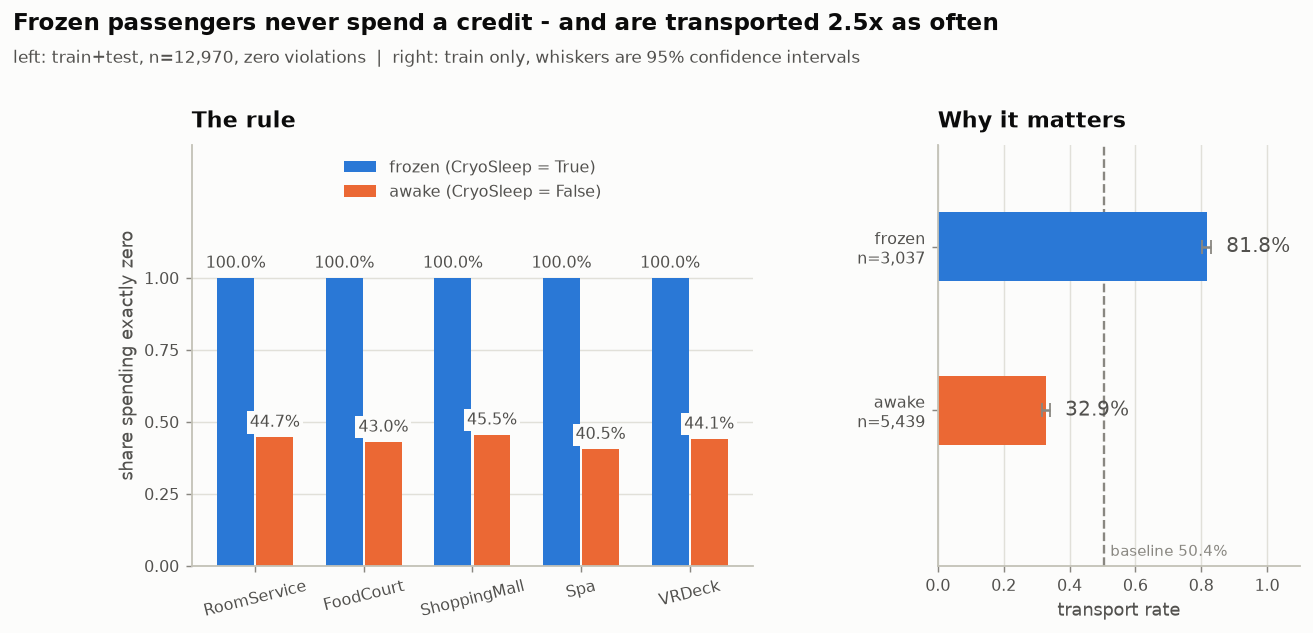

In [14]:
# ---- HIGHLIGHT CHART 1 -----------------------------------------------------
# Left panel  : the rule        (share of passengers spending exactly zero)
# Right panel : why it matters  (transport rate, frozen vs awake)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2),
                               gridspec_kw={"width_ratios": [1.55, 1]})

# --- left: the rule ---
zero_frozen = [(frozen[c].fillna(0) == 0).mean() for c in L.SPEND_COLS]
zero_awake  = [(awake[c] == 0).mean() for c in L.SPEND_COLS]
x, w = np.arange(len(L.SPEND_COLS)), 0.34
# A small gap between the two fills, so a wide label cannot sit on its neighbour.
bf = axL.bar(x - 0.18, zero_frozen, w, color=viz.SERIES[0], label="frozen (CryoSleep = True)")
ba = axL.bar(x + 0.18, zero_awake,  w, color=viz.SERIES[1], label="awake (CryoSleep = False)")

def label_clear(ax, bars, vals):
    """Direct labels with a surface-coloured backing, so a label that is wider
    than its bar stays readable over whatever sits behind it."""
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.022, f"{v:.1%}",
                ha="center", va="bottom", fontsize=9, color=viz.INK_SECONDARY,
                bbox=dict(facecolor=viz.SURFACE, edgecolor="none", pad=1.6), zorder=6)

label_clear(axL, bf, zero_frozen)
label_clear(axL, ba, zero_awake)
axL.set_xticks(x, L.SPEND_COLS, rotation=14)
axL.set_ylim(0, 1.46)
axL.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
axL.set_ylabel("share spending exactly zero")
axL.set_title("The rule", loc="left", pad=10)
axL.legend(loc="upper center", ncols=1)
viz.clean(axL)

# --- right: why it matters ---
rt = cryo_rates.reindex(["awake", "frozen"])
y = np.arange(2)
axR.barh(y, rt["rate"], 0.42, color=[viz.SERIES[1], viz.SERIES[0]], zorder=2)
axR.errorbar(rt["rate"], y, xerr=[rt["rate"] - rt["lo"], rt["hi"] - rt["rate"]],
             fmt="none", ecolor=viz.INK_MUTED, capsize=4, lw=1.4, zorder=3)
for yi, (r, hi) in enumerate(zip(rt["rate"], rt["hi"])):
    axR.text(hi + 0.045, yi, f"{r:.1%}", va="center", ha="left",
             fontsize=11, color=viz.INK_SECONDARY)
axR.set_yticks(y, [f"{lab}\nn={n:,}" for lab, n in zip(rt.index, rt["n"])])
axR.set_xlim(0, 1.10)
axR.set_ylim(-0.95, 1.62)
axR.set_xlabel("transport rate")
axR.set_title("Why it matters", loc="left", pad=10)
viz.clean(axR, which="x")

# Baseline labelled at the BOTTOM of the panel, clear of the title and the bars.
axR.axvline(rate, color=viz.INK_MUTED, linestyle="--", lw=1.3, zorder=1)
axR.text(rate + 0.02, 0.015, f"baseline {rate:.1%}", transform=axR.get_xaxis_transform(),
         va="bottom", ha="left", fontsize=8.5, color=viz.INK_MUTED)

fig.subplots_adjust(wspace=0.40)
show(fig, "05_cryosleep_rule_and_payoff",
     "Frozen passengers never spend a credit - and are transported 2.5x as often",
     "left: train+test, n=12,970, zero violations  |  right: train only, whiskers are 95% confidence intervals")

### How to read this chart

**Left panel.** Each pair of bars is one service. The blue bar is frozen passengers, the orange
bar is awake ones. All five blue bars sit at exactly 100% — every frozen passenger spent zero on
every service. The orange bars sit around 40–46%, because plenty of awake passengers also happen
not to use a given service. The contrast between a flat 100% and a scattered 40-something is
what tells you the first one is a *rule* and the second is just *behaviour*.

**Right panel.** The payoff. Frozen passengers were transported **81.8%** of the time; awake
passengers only **32.9%**. The dashed line is our 50.4% baseline from section 1, so frozen sits
far above it and awake far below.

The little horizontal whiskers on the bars are **confidence intervals** — a visual statement of
how precise each estimate is. They are narrow here because both groups have thousands of
passengers. In section 9 we will meet a group where they are not narrow at all.

**Watch out though.** Because being awake is so strongly tied to being transported, *anything
else that only awake people do* will inherit that signal. That is exactly the trap the next
section is about.

## 6. ★ HIGHLIGHT 2 — confounding, the most useful idea in this notebook

There are five things a passenger could spend money on: `RoomService`, `FoodCourt`,
`ShoppingMall`, `Spa`, `VRDeck`.

A very reasonable first move is to add them into one `TotalSpend` column and ask "do big
spenders get transported more or less?" Let us do the naive version first and see what it says.

In [15]:
naive = []
for c in L.SPEND_COLS:
    sub = train[train[c].notna()]
    spent = sub[c] > 0
    naive.append({
        "service": c,
        "rate_spent": sub.loc[spent, L.TARGET].mean(),
        "rate_zero":  sub.loc[~spent, L.TARGET].mean(),
    })
naive = pd.DataFrame(naive)
naive["gap_pp"] = (naive["rate_spent"] - naive["rate_zero"]) * 100
naive.round(3)

,service,rate_spent,rate_zero,gap_pp
0,RoomService,0.260,0.633,-37.335
1,FoodCourt,0.345,0.591,-24.546
2,ShoppingMall,0.317,0.599,-28.160
3,Spa,0.277,0.639,-36.172
4,VRDeck,0.275,0.628,-35.261


Every single service has a **negative** gap. Spending money on anything appears to lower your
chance of being transported. The obvious conclusion: "spending is bad, roll it into one column,
move on."

**That conclusion is wrong, and section 5 already told us why.**

Spending money requires being awake. Awake passengers are transported only 32.9% of the time.
So *any* behaviour that only awake people can do will look negative — not because the behaviour
matters, but because it is a marker for being awake.

This is **confounding**: a third variable (`CryoSleep`) sitting behind both the thing we are
measuring and the outcome, creating an association that is not really about spending at all.

### The fix: compare like with like

The cure is to **stratify** — look only within a group where the confounder is held constant.
Here that means: *among awake passengers only*, does spending on a given service still matter?

Everyone in this comparison is awake, so being awake can no longer explain any difference we
find.

In [16]:
aw = train[train["CryoSleep"] == False]

honest = []
for c in L.SPEND_COLS:
    sub = aw[aw[c].notna()]
    m = sub[c] > 0
    p1, n1 = sub.loc[m, L.TARGET].mean(),  int(m.sum())
    p0, n0 = sub.loc[~m, L.TARGET].mean(), int((~m).sum())
    se = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)   # standard error of the gap
    honest.append({"service": c, "rate_spent": p1, "rate_zero": p0,
                   "gap_pp": (p1 - p0) * 100, "se_pp": se * 100,
                   "z": (p1 - p0) / se})
honest = pd.DataFrame(honest)
honest["verdict"] = np.where(honest["z"].abs() <= 1.96, "flat",
                      np.where(honest["gap_pp"] > 0, "raises", "lowers"))

print(f"awake passengers only: n={len(aw):,}, their baseline rate = {aw[L.TARGET].mean():.1%}")
honest.round(3)

awake passengers only: n=5,439, their baseline rate = 32.9%


,service,rate_spent,rate_zero,gap_pp,se_pp,z,verdict
0,RoomService,0.260,0.411,-15.065,1.287,-11.710,lowers
1,FoodCourt,0.346,0.308,3.756,1.291,2.910,raises
2,ShoppingMall,0.318,0.342,-2.409,1.290,-1.867,flat
3,Spa,0.278,0.401,-12.295,1.315,-9.349,lowers
4,VRDeck,0.276,0.394,-11.725,1.297,-9.039,lowers


The picture changes completely.

- `RoomService`, `Spa`, `VRDeck` stay clearly **negative**, and in fact get stronger.
- `FoodCourt` **flips sign** — spending there now *raises* your chance of being transported.
- `ShoppingMall` goes **flat** — its gap is small enough that we cannot distinguish it from zero.

The `z` column is how many standard errors the gap sits from zero. A rough rule: **|z| above
about 2 means the gap is unlikely to be chance; below 2, treat it as noise.** `ShoppingMall` has
z = −1.87, which is under the bar — so we call it flat rather than negative.

Let us draw the before-and-after.

  -> figures/nb/06_confounding_dumbbell.png


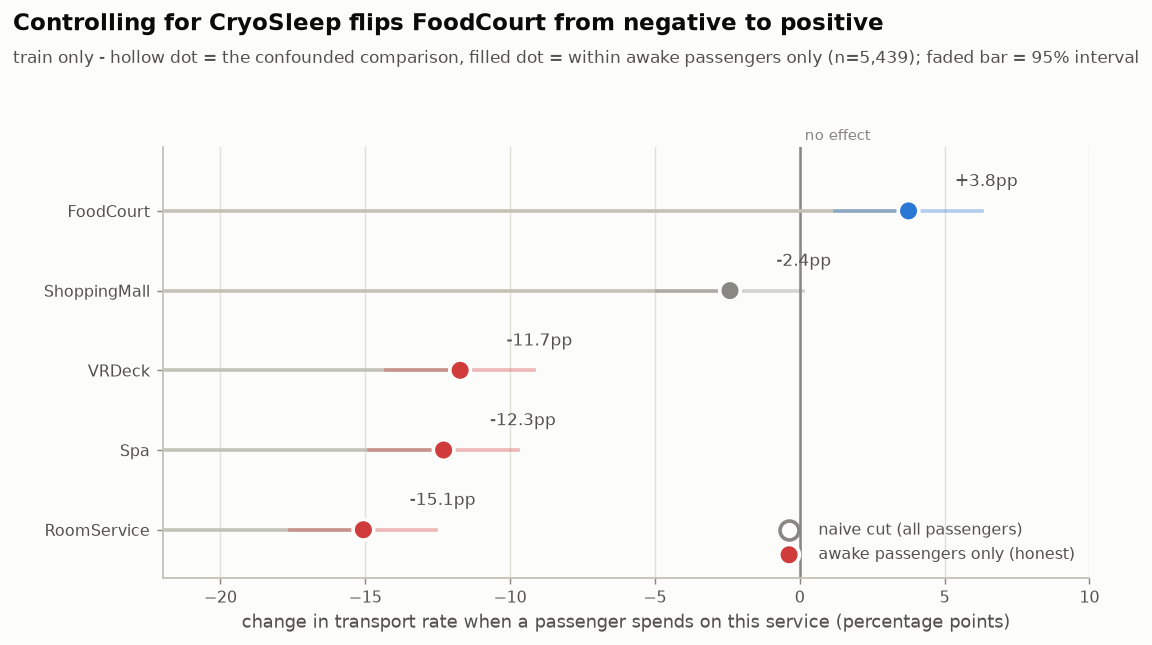

In [17]:
# ---- HIGHLIGHT CHART 2 -----------------------------------------------------
# A "dumbbell": for each service, the naive gap and the honest gap, connected.
# The whole point of the chart is which dots cross the zero line.

both = honest.merge(naive[["service", "gap_pp"]], on="service", suffixes=("", "_naive"))
both = both.sort_values("gap_pp")

VERDICT_COLOR = {"lowers": "#d03b3b", "raises": "#2a78d6", "flat": viz.INK_MUTED}

fig, ax = plt.subplots(figsize=(9.2, 4.3))
y = np.arange(len(both))

ax.axvline(0, color=viz.INK_MUTED, lw=1.4, zorder=1)
ax.text(0, 1.008, " no effect", transform=ax.get_xaxis_transform(),
        va="bottom", ha="left", fontsize=8.5, color=viz.INK_MUTED)

for yi, r in zip(y, both.itertuples()):
    ax.plot([r.gap_pp_naive, r.gap_pp], [yi, yi], color=viz.BASELINE, lw=2, zorder=2)
    # 95% interval on the honest estimate
    ax.plot([r.gap_pp - 1.96 * r.se_pp, r.gap_pp + 1.96 * r.se_pp], [yi, yi],
            color=VERDICT_COLOR[r.verdict], lw=2, alpha=0.35, zorder=3)

ax.scatter(both["gap_pp_naive"], y, s=110, facecolor=viz.SURFACE,
           edgecolor=viz.INK_MUTED, linewidth=2, zorder=4, label="naive cut (all passengers)")
ax.scatter(both["gap_pp"], y, s=130,
           color=[VERDICT_COLOR[v] for v in both["verdict"]],
           edgecolor=viz.SURFACE, linewidth=2, zorder=5,
           label="awake passengers only (honest)")

for yi, r in zip(y, both.itertuples()):
    off = 1.6 if r.gap_pp >= r.gap_pp_naive else -1.6
    ax.text(r.gap_pp + off, yi + 0.26, f"{r.gap_pp:+.1f}pp",
            va="bottom", ha="left" if off > 0 else "right",
            fontsize=9.5, color=viz.INK_SECONDARY)

ax.set_yticks(y, both["service"])
ax.set_xlabel("change in transport rate when a passenger spends on this service "
              "(percentage points)")
ax.set_xlim(-22, 10)
ax.set_ylim(-0.6, len(both) - 0.2)
ax.legend(loc="lower right", ncols=1)
viz.clean(ax, which="x")

show(fig, "06_confounding_dumbbell",
     "Controlling for CryoSleep flips FoodCourt from negative to positive",
     "train only - hollow dot = the confounded comparison, filled dot = within awake passengers "
     "only (n=5,439); faded bar = 95% interval")

### How to read this chart

Each row is one service. Read left to right as "bad for you" to "good for you".

- The **hollow dot** is the naive answer — all passengers lumped together. Every hollow dot sits
  to the left of the zero line, which is the misleading result we started with.
- The **filled dot** is the honest answer — awake passengers only.
- The **grey bar between them** is how much the confounder was distorting things.
- The **faded coloured bar** around each filled dot is its 95% interval: the range of values
  consistent with the data. If that bar touches the zero line, we cannot claim a direction.

Now the punchline is visual. `FoodCourt` is the one row whose filled dot has crossed to the
**right** of zero. `ShoppingMall`'s interval still overlaps zero, so it stays grey and we say
nothing about its direction.

### Why this matters practically

If you had summed the five columns into one `TotalSpend`, you would have averaged a strong
negative (`RoomService`, −15.1pp), a genuine positive (`FoodCourt`, +3.8pp) and a nothing
(`ShoppingMall`) into a single mush, and destroyed the distinction.

The three negative ones — room service, spa, VR deck — are all **private, in-cabin** services.
`FoodCourt` is the one you have to leave your cabin for. Whether that is the real mechanism we
cannot prove from this data alone, but it is a sensible story and it matches the pattern.

> **The transferable lesson:** when a comparison gives you a result, ask *"what else is
> different between these two groups?"* If you can name something, stratify on it and look
> again. This one habit will catch more mistakes than any modelling technique.

## 7. ★ HIGHLIGHT 3 — the ID column that predicts the answer

Back to `PassengerId` = `gggg_pp`. We established in section 4 that `gggg` is a travel group.

Now the real question: **if you know what happened to someone's travelling companion, does that
tell you anything about them?**

To answer it we take every pair of people inside the same unit and count how often their fates
agree. We use the project's own `pair_concordance` function so the numbers match `FINDINGS.md`
exactly.

In [18]:
import importlib.util

spec = importlib.util.spec_from_file_location("groups_mod", ROOT / "src" / "02_groups.py")
groups_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(groups_mod)

# An exact-cabin key, so we can compare "same cabin" with "same group" and "same surname".
train2 = train.copy()
train2["CabinKey"] = train2["Cabin"]

units = {"travel group": "Group", "surname (family)": "Surname", "exact cabin": "CabinKey"}
rows = []
for label, key in units.items():
    r = groups_mod.pair_concordance(train2, key)
    rows.append({"unit": label, "pairs": r["pairs"],
                 "mate_T_given_ego_T": r["p_mate_t_given_ego_t"],
                 "mate_T_given_ego_F": r["p_mate_t_given_ego_f"]})
conc = pd.DataFrame(rows)
conc["swing_pp"] = (conc["mate_T_given_ego_T"] - conc["mate_T_given_ego_F"]) * 100
conc.round(4)

,unit,pairs,mate_T_given_ego_T,mate_T_given_ego_F,swing_pp
0,travel group,4501,0.6074,0.5148,9.2639
1,surname (family),18804,0.5161,0.4700,4.6171
2,exact cabin,3323,0.6500,0.5456,10.4407


Read the first row like this: among people who share a travel group, if I tell you one member
was transported, the chance their companion was also transported is **60.7%**. If I tell you the
member was *not* transported, it drops to **51.5%**.

Against a 50.4% baseline, that is a real, usable shift — from a column most people delete.

Two things worth noticing straight away:

- **Sharing a cabin is a stronger link than sharing a group, which beats sharing a surname.**
- **Fate is correlated, not determined.** 60.7% is a long way from 95%. Groups were *not*
  transported wholesale, which is a much more interesting dataset than if they had been.

  -> figures/nb/07_companion_fate.png


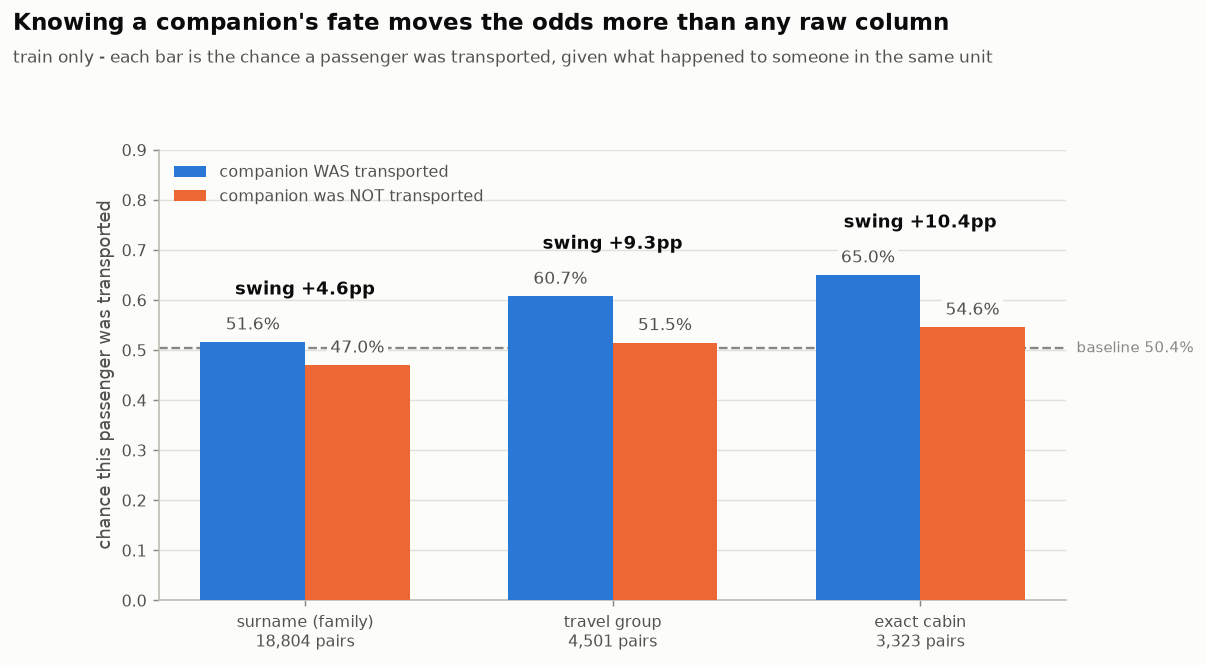

In [19]:
# ---- HIGHLIGHT CHART 3 -----------------------------------------------------
# Rebuilt from the project version, with two fixes: the palette tokens instead of
# matplotlib's defaults, and value labels that the baseline rule cannot run through.

c = conc.sort_values("swing_pp")
fig, ax = plt.subplots(figsize=(9.0, 4.5))
x, w = np.arange(len(c)), 0.34

b1 = ax.bar(x - w/2, c["mate_T_given_ego_T"], w, color=viz.SERIES[0],
            label="companion WAS transported", zorder=3)
b2 = ax.bar(x + w/2, c["mate_T_given_ego_F"], w, color=viz.SERIES[1],
            label="companion was NOT transported", zorder=3)

def label_clear(bars, vals):
    """Direct labels with a surface-coloured backing, so the dashed baseline
    cannot cut through the text where a bar happens to end near it."""
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.017, f"{v:.1%}",
                ha="center", va="bottom", fontsize=9.5, color=viz.INK_SECONDARY,
                bbox=dict(facecolor=viz.SURFACE, edgecolor="none", pad=1.8), zorder=6)

label_clear(b1, c["mate_T_given_ego_T"])
label_clear(b2, c["mate_T_given_ego_F"])

for xi, r in zip(x, c.itertuples()):
    top = max(r.mate_T_given_ego_T, r.mate_T_given_ego_F)
    ax.annotate(f"swing {r.swing_pp:+.1f}pp", (xi, top + 0.095),
                ha="center", fontsize=10, color=viz.INK, fontweight="bold", zorder=6)

ax.set_xticks(x, [f"{u}\n{p:,} pairs" for u, p in zip(c["unit"], c["pairs"])])
ax.set_ylabel("chance this passenger was transported")
ax.set_ylim(0, 0.90)
ax.legend(loc="upper left", ncols=1)
viz.clean(ax)

# Baseline drawn behind the bars, labelled in the RIGHT margin where nothing else sits.
ax.axhline(rate, color=viz.INK_MUTED, linestyle="--", lw=1.3, zorder=1)
ax.text(1.006, rate, f" baseline {rate:.1%}", transform=ax.get_yaxis_transform(),
        va="center", ha="left", fontsize=8.5, color=viz.INK_MUTED)

show(fig, "07_companion_fate",
     "Knowing a companion's fate moves the odds more than any raw column",
     "train only - each bar is the chance a passenger was transported, given what happened "
     "to someone in the same unit")

### How to read this chart

Three units, ordered weakest to strongest link. For each one, the blue bar is "your companion
*was* transported" and the orange bar is "your companion was *not*". The gap between them — the
**swing** — is how much the companion's fate tells you.

Surname barely moves the needle (+4.6pp). Travel group moves it +9.2pp. Sharing an exact cabin
moves it +10.4pp.

### The check that makes this trustworthy

There is a subtle problem with counting pairs: a group of 10 people contributes 45 pairs, while
a group of 2 contributes 1. Large groups therefore dominate the average, and if large groups
behave unusually the whole result could be an artefact of that rather than a real effect.

`FINDINGS.md` records the test for this: the analysis was re-run on **size-2 units only**, where
every unit contributes exactly one pair and no group can dominate. The effect got **stronger**,
not weaker — the cabin swing rose to +13.8pp and the group swing to +10.3pp.

That is what turns an interesting number into a finding you can rely on.

> **The habit:** when a result depends on how you counted, find a way to count differently and
> check it survives. If it does, you have something. If it does not, you nearly shipped a bug.

### One caution on interpretation

Cabin-mates are mostly *also* groupmates, and they are also the closest social tie. So this
chart cannot cleanly separate "being in the same place" from "being related to each other". Read
it as a pattern that is definitely there, not as a proven mechanism.

## 8. The rest of the findings, briefly

The three highlights are the ideas worth internalising. The dataset has nine more findings that
are worth knowing but do not each need a full lesson. The charts below were produced by the
scripts in `src/` — the full write-up for every one of them is in `FINDINGS.md`.

### 8a. Travelling alone costs you 11 points

55% of passengers travel solo. They were transported at **45.2%**; anyone in a group, at
**56.7%**. The rate climbs to a peak at group size 4 and then falls back — but the larger sizes
have few passengers, so treat the solo-versus-grouped split as the finding and the exact shape
of the curve as decoration.

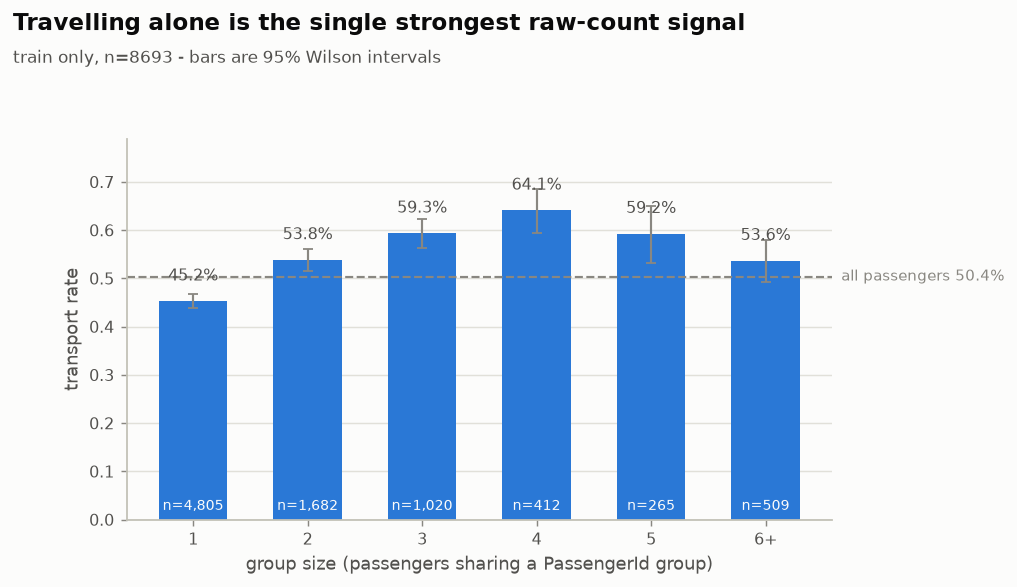

In [20]:
display(Image(str(ROOT / "figures" / "02_rate_by_groupsize.png")))

### 8b. Some columns are perfectly constant within a group — which turns guessing into lookup

`HomePlanet` is the same for every member of a travel group. Not *usually* the same —
**always**, across 9,124 multi-member groups, with zero exceptions. The same holds within a
surname, and `Side` (port or starboard) is also perfectly constant within a group.

`Deck` is not constant, and neither is `Destination` or `CryoSleep`.

This matters for the missing-data problem in section 3. A missing `HomePlanet` is not a gap to
be filled with the most common value — it is a **lookup**. Find anyone with the same surname and
copy their value across.

In [21]:
for key, attr in [("Group", "HomePlanet"), ("Surname", "HomePlanet"), ("Group", "Side")]:
    share, n = groups_mod.constancy(combined, key, attr)
    print(f"{attr:11s} constant within {key:8s}: {share:.1%}  (across {n:,} multi-member units)")
print()
for key, attr in [("Surname", "HomePlanet"), ("Group", "HomePlanet")]:
    missing, fillable = groups_mod.recoverable(combined, key, attr)
    print(f"missing {attr} with a known {key:8s}: {missing:4d} -> recoverable: "
          f"{fillable:4d} ({fillable / missing:.1%})")

HomePlanet  constant within Group   : 100.0%  (across 2,134 multi-member units)
HomePlanet  constant within Surname : 100.0%  (across 2,197 multi-member units)
Side        constant within Group   : 100.0%  (across 2,134 multi-member units)

missing HomePlanet with a known Surname :  278 -> recoverable:  271 (97.5%)
missing HomePlanet with a known Group   :  288 -> recoverable:  131 (45.5%)


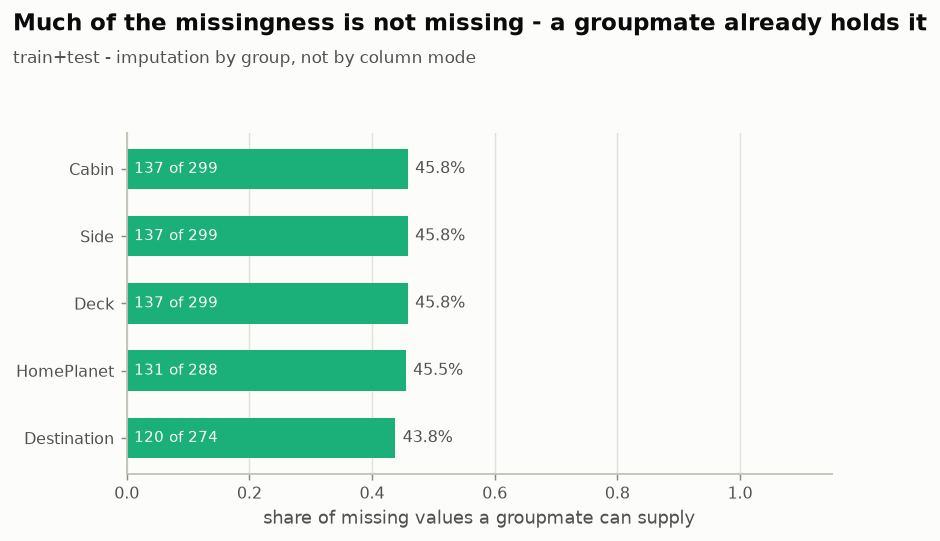

In [22]:
display(Image(str(ROOT / "figures" / "02_recoverable_missing.png")))

### 8c. Nobody under 13 spends a single credit — and the switch flips exactly at 13

Remember the `Age == 0` question from section 2? Here is the answer, plus a sharp discrete rule.

In [23]:
# Is Age == 0 a real infant, or a code for "missing"?
print(f"rows with Age == 0        : {(combined['Age'] == 0).sum()}")
print(f"rows with Age missing     : {combined['Age'].isna().sum()}")
print("--> Age has its own separate NaNs, so 0 is NOT a missing-value code.")
print("    Those are genuine infants.")
print()

kids = combined[combined["Age"] < 13]
spent_kids = (kids[L.SPEND_COLS].fillna(0) > 0).any(axis=1).sum()
print(f"passengers aged 0-12      : {len(kids):,}")
print(f"...with any nonzero charge: {spent_kids}")
print()
at13 = combined[combined["Age"] == 13]
print(f"passengers aged exactly 13: {len(at13)}")
print(f"...with any nonzero charge: {(at13[L.SPEND_COLS].fillna(0) > 0).any(axis=1).mean():.0%}")

rows with Age == 0        : 260
rows with Age missing     : 270
--> Age has its own separate NaNs, so 0 is NOT a missing-value code.
    Those are genuine infants.

passengers aged 0-12      : 1,157
...with any nonzero charge: 0

passengers aged exactly 13: 219
...with any nonzero charge: 53%


A hard switch at exactly 13 — another rule of the data generator, not a smooth trend.

And the age effect is *not* simply a side effect of children being frozen more often. Among
**awake passengers only**, under-13s were transported at 68.2% versus 30.5% for awake adults —
a gap that is *wider* than the unstratified one. (That is the section 6 habit applied again:
suspect a confounder, stratify, look.)

Ages 18–65 are flat at 46–49%. Essentially the entire age signal lives under 18.

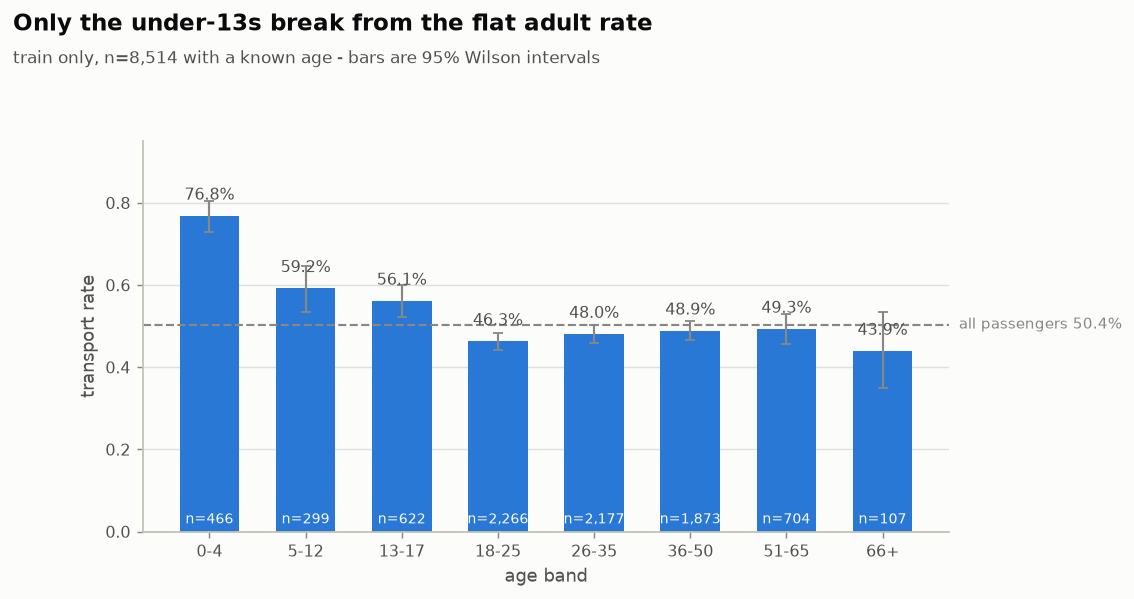

In [24]:
display(Image(str(ROOT / "figures" / "05_rate_by_age.png")))

### 8d. Starboard beats port on every single deck

Overall, starboard passengers were transported at 55.5% versus 45.1% for port — a 10.4pp gap.

What makes this convincing is not the overall number, it is that **the direction holds on all
seven populated decks without exception**. Seven independent slices all pointing the same way is
much stronger evidence than one aggregate difference, which could be driven by a single deck.

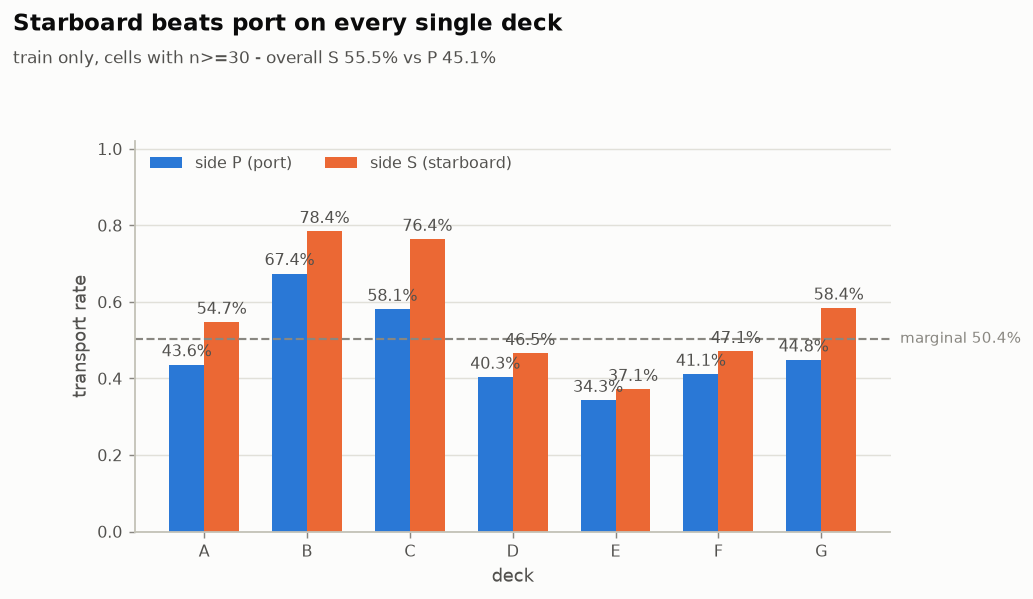

In [25]:
display(Image(str(ROOT / "figures" / "03_side_by_deck.png")))

### 8e. Deck and home planet are largely the same fact

Decks A, B, C and T are 100% Europa passengers. Deck G is 100% Earth. Only D, E and F are mixed.

So "deck matters" and "home planet matters" are substantially **the same finding**, and you
should not count them as two independent pieces of evidence.

But deck is not *purely* a stand-in for origin. Within a single home planet the deck rate still
swings hard — Mars passengers on deck F were transported at 65.0% versus 26.1% on deck E. There
is real information in deck beyond where someone came from.

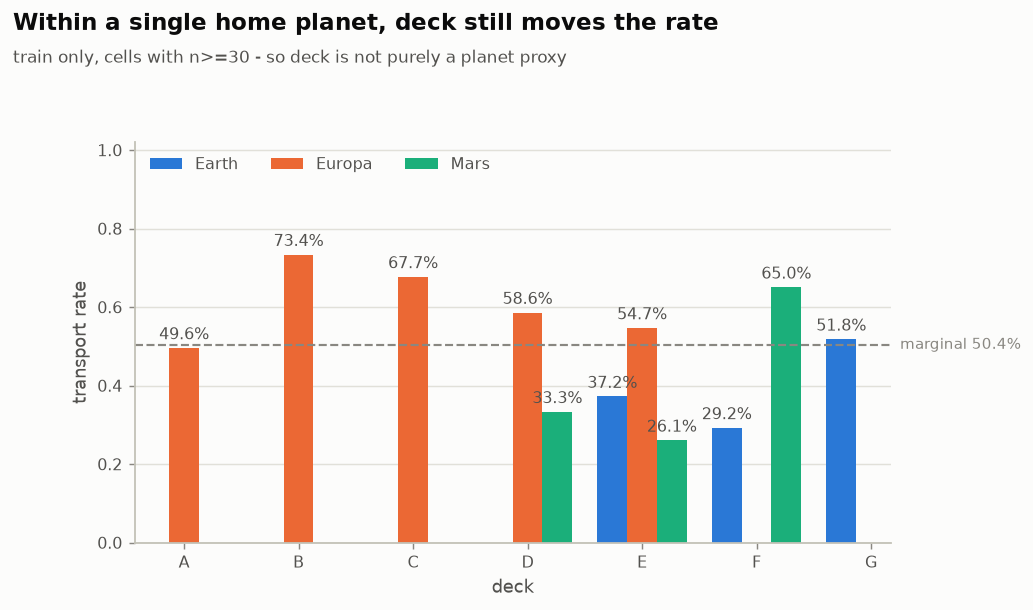

In [26]:
display(Image(str(ROOT / "figures" / "03_deck_within_homeplanet.png")))

### 8f. The cabin number is a position, not an identifier

Of 2,068 multi-member groups with a cabin, 1,397 (67.6%) occupy one identical cabin. The other
671 are not next door — every one of them spans more than one deck, and the median such group
spans 254 cabin numbers. So a group either shares a single cabin or is scattered across the ship;
there is no "adjacent cabins" case at all.

The number itself carries signal: sweeping along cabin numbers *within* a deck, the transport
rate moves by 0.363 on deck G.

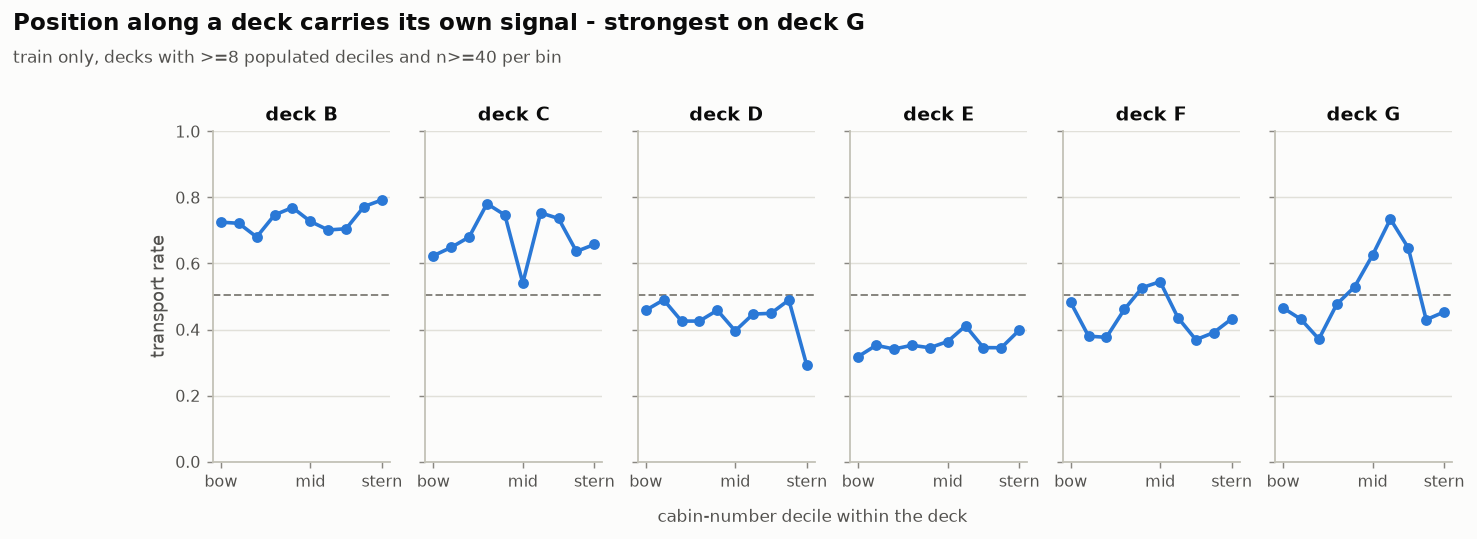

In [27]:
display(Image(str(ROOT / "figures" / "03_rate_by_cabinnum.png")))

### 8g. Where you came from beats where you were going

Home planet is clean and strong: **Europa 65.9%, Mars 52.3%, Earth 42.4%.**

Destination is the weakest categorical, but it does not vanish once you control for origin —
Earth passengers heading to TRAPPIST-1e sit about 11 points below Earth passengers heading
anywhere else, on 3,101 rows. So "destination is just origin in disguise" overstates it.

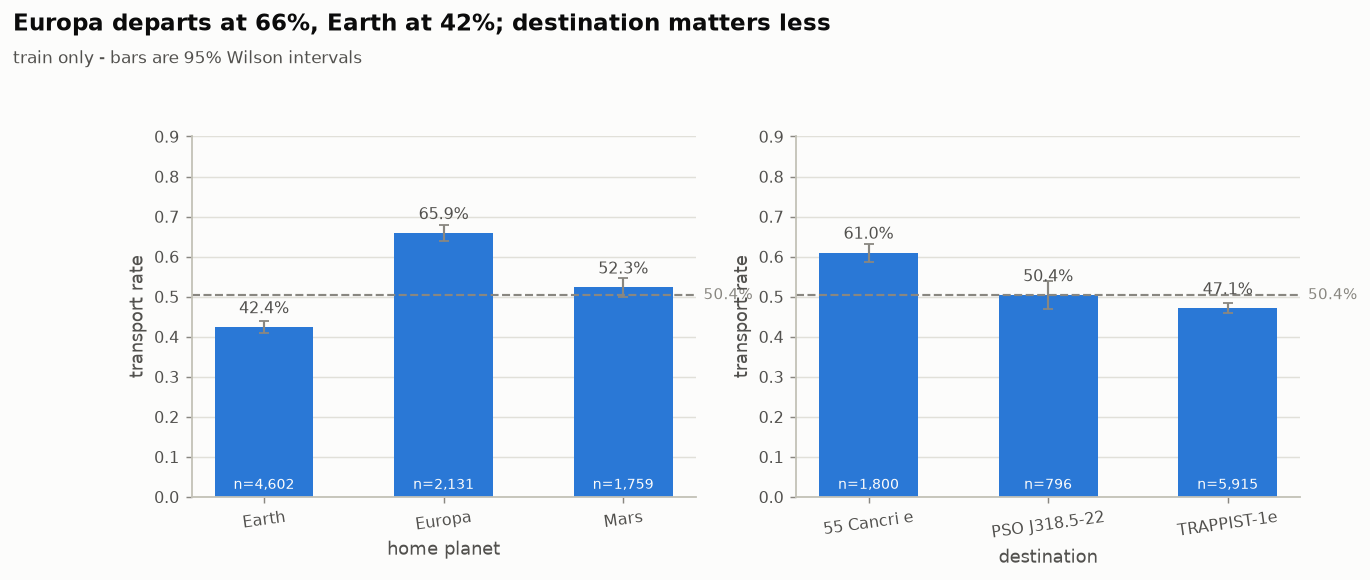

In [28]:
display(Image(str(ROOT / "figures" / "05_rate_by_origin_destination.png")))

## 9. Uncertainty — when is a difference real?

Every rate we have computed is an **estimate** from a sample, not a fact. A rate measured on
5,000 people is far more trustworthy than the same rate measured on 50.

A **confidence interval** puts that into numbers. The 95% interval is the range of true values
consistent with what we observed. Read it as: *"the real rate is probably somewhere in here."*

`src/viz.py` provides `wilson()`, which computes the Wilson score interval. It is used instead
of the textbook formula because the textbook one misbehaves badly when a rate is near 0% or 100%
or when the group is small — exactly the cases where you most need an honest answer.

The `VIP` column is the perfect demonstration.

In [29]:
vip = viz.rate_table(train[train["VIP"].notna()], "VIP")
vip["ci_width_pp"] = (vip["hi"] - vip["lo"]) * 100
vip[["n", "rate", "lo", "hi", "ci_width_pp"]].round(4)

,n,rate,lo,hi,ci_width_pp
VIP,,,,,
False,8291,0.5063,0.4956,0.5171,2.1519
True,199,0.3819,0.3172,0.4510,13.3800


In [30]:
print(f"VIPs are {(combined['VIP'] == True).sum()} of {combined['VIP'].notna().sum():,} "
      f"passengers ({(combined['VIP'] == True).mean():.1%} of the ship)")
print()
w_vip = (vip.loc[True, "hi"] - vip.loc[True, "lo"]) * 100
w_non = (vip.loc[False, "hi"] - vip.loc[False, "lo"]) * 100
print(f"interval width, VIP     : {w_vip:.1f}pp")
print(f"interval width, non-VIP : {w_non:.1f}pp")
print(f"--> the VIP interval is {w_vip / w_non:.0f}x wider, purely because there are so few VIPs")

VIPs are 273 of 12,674 passengers (2.1% of the ship)

interval width, VIP     : 13.4pp
interval width, non-VIP : 2.2pp
--> the VIP interval is 6x wider, purely because there are so few VIPs


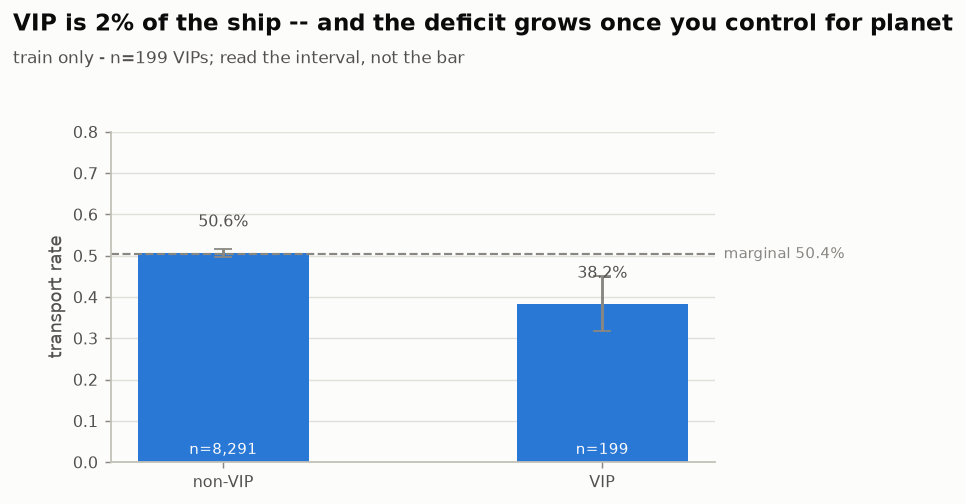

In [31]:
display(Image(str(ROOT / "figures" / "05_vip.png")))

The two intervals do not overlap, so the VIP deficit is real — VIPs were transported less often.
But the VIP interval is roughly six times wider, so we know that fact far less precisely.

There is also a nice twist here that rewards the section 6 habit. **Not one VIP came from
Earth** — they are 66% Europa, 34% Mars, and Europa has the highest transport rate of the three
planets. So the planet mix was *hiding* part of the VIP effect. Stratify by planet and the gap
gets *wider*, not narrower:

| planet | VIP rate | non-VIP rate | gap |
|---|---:|---:|---:|
| Europa | 48.9% (n=131) | 67.0% (n=1,958) | **−18.2pp** |
| Mars | 15.9% (n=63) | 53.4% (n=1,653) | **−37.6pp** |

Against −12.4pp unconditionally. Same technique as the FoodCourt flip, opposite consequence:
there, controlling for the confounder *reversed* a finding; here it *strengthened* one. Both are
what "compare like with like" looks like in practice.

> **Rule of thumb:** always print `n` next to a rate. A rate without a sample size behind it is
> not yet a fact.

## 10. What this all means for building a model

You now know more about this dataset than most people who jump straight to fitting a classifier.
If you want to go on and build one, the analysis points to five concrete moves:

1. **Decode `PassengerId`, `Cabin` and `Name` before anything else.** That is where the signal
   is. Everything in sections 4 and 7 depends on this step.
2. **Fill missing values by lookup, not by column average.** Use group and surname for
   `HomePlanet` and `Side`; fill cryo-implied spending with 0; recover missing `CryoSleep` from
   nonzero spending.
3. **Keep the five spending columns separate.** Section 6 is the reason. Add a binary
   "spent anything at all" flag, which on its own is nearly as strong as `CryoSleep`
   (78.7% for non-spenders versus 29.9% for spenders).
4. **Add an `Age < 13` flag**, and group-level aggregates — group size, how much the rest of the
   group spent, whether the rest of the group was frozen. Section 7 says a companion's
   attributes predict yours.
5. **Do not treat deck and home planet as two independent signals.** Section 8e.

### One trap to know about before you split your data

There is a detail here that catches people out. **No travel group straddles the train/test
split** — Kaggle divided the data group-wise. So group features carry no leakage between the
two files.

But **surnames do straddle**: 1,536 of the 2,217 surnames in `train` also appear in `test`. A
surname-level feature therefore crosses the boundary. That is legitimate for this competition,
but if you build your own validation split by picking random rows, you will leak information
between your training and validation sets and your score will look better than it really is.

**Split by group, not by row.**

> **Leakage** is when information that would not be available at prediction time sneaks into
> training. It is the most common way a model looks brilliant in development and fails in
> production.

### Do not take my word for it — check the split yourself

Both claims above are checkable, and `src/load.py` ships the check. `verify()` re-derives the
structural facts this notebook has been relying on and prints them: that every `PassengerId`
parsed cleanly, how many travel groups span both files, and how many surnames do.

This is a habit worth copying. When an analysis rests on a structural assumption — "the split is
group-wise", "this id is unique", "these two files do not overlap" — write the check as code and
run it, rather than trusting a sentence in someone's write-up (including this one).

In [32]:
failures = L.verify(train, test, combined)
print()
print(f"parse failures: {failures}  <- must be 0 for anything above to hold")

STRUCTURAL DECODE VERIFICATION

rows: train=8693  test=4277  combined=12970
train columns: 27  test columns: 26
target present in train: True | in test: False

[1] PassengerId 'gggg_pp' parse failures: 0
    PassengerId unique: True
    PassengerId nulls : 0
    distinct groups   : 9280
    MemberNo range    : 1..8
    groups spanning BOTH train and test: 0 of 9280

[2] Cabin 'deck/num/side' parse failures (non-null Cabin): 0
    Cabin nulls: 299
    decks: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']
    sides: ['P', 'S']
    CabinNum range: 0..1894

[3] Name 'first surname' parse failures (non-null Name): 0
    Name nulls: 294
    distinct surnames: 2406
    name token counts: {2: 12676}

[4] derived features
    GroupSize   range: 1..8
    SurnameSize range: 1.0..19.0
    TotalSpend  nulls: 0
    rows with a PARTIAL TotalSpend (1-4 services NaN): 1363
    rows with all 5 services NaN: 0

PASS: total parse failures = 0

parse failures: 0  <- must be 0 for anything above to hold


## Glossary

| Term | Plain meaning |
|---|---|
| **EDA** | Exploratory data analysis — looking at data to understand it before modelling |
| **Baseline / marginal rate** | How often the outcome happens overall (50.4% here). The number every result is judged against |
| **pp (percentage points)** | The arithmetic difference between two percentages. 50% → 65% is +15pp |
| **Feature engineering** | Building new, more useful columns out of the raw ones |
| **Confounding** | A hidden third variable that makes two things look related when the relationship is really about the third thing |
| **Stratify** | Split into groups where the confounder is constant, then compare inside a group |
| **Confidence interval** | The range of true values consistent with what you observed. Wide = imprecise |
| **Wilson interval** | A confidence interval for a proportion that stays sensible near 0%, near 100%, and on small groups |
| **z score** | How many standard errors an estimate sits from zero. Roughly, \|z\| > 2 means "probably not chance" |
| **Cramér's V** | How strongly two categorical columns are associated. 0 = unrelated, 1 = one determines the other |
| **Leakage** | Information reaching the model that it would not have in real use, inflating the score |
| **Deterministic rule** | A constraint that holds with zero exceptions, so it can fill missing values with certainty |

## Where to go next

- `FINDINGS.md` — the full expert write-up. Every claim in this notebook traces back to it.
- `output/*.log` — the raw numbers behind every figure.
- `src/0*.py` — the five analysis scripts. Run any of them with `.venv/bin/python src/01_overview.py`.

**A good next exercise:** pick one finding and try to break it. Re-run it on a different slice,
count it a different way, and see whether it survives. That is section 7's robustness check, and
it is the single most valuable habit in this whole notebook.